In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import  accuracy_score, classification_report,confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [25]:
df = pd.read_csv('diabetes.csv')

In [26]:
df


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [27]:
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 24.9:
        return 'Healthy weight'
    elif 25 <= bmi < 29.9:
        return 'Overweight'
    else:
        return 'Obese'
df['BMI_category']= df['BMI'].apply(bmi_category)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_category
0,6,148,72,35,0,33.6,0.627,50,1,Obese
1,1,85,66,29,0,26.6,0.351,31,0,Overweight
2,8,183,64,0,0,23.3,0.672,32,1,Healthy weight
3,1,89,66,23,94,28.1,0.167,21,0,Overweight
4,0,137,40,35,168,43.1,2.288,33,1,Obese
...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,Obese
764,2,122,70,27,0,36.8,0.340,27,0,Obese
765,5,121,72,23,112,26.2,0.245,30,0,Overweight
766,1,126,60,0,0,30.1,0.349,47,1,Obese


In [28]:
df[df["BMI_category"]==True]
df = df.dropna()

In [29]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_category
0,6,148,72,35,0,33.6,0.627,50,1,Obese
1,1,85,66,29,0,26.6,0.351,31,0,Overweight
2,8,183,64,0,0,23.3,0.672,32,1,Healthy weight
3,1,89,66,23,94,28.1,0.167,21,0,Overweight
4,0,137,40,35,168,43.1,2.288,33,1,Obese
...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,Obese
764,2,122,70,27,0,36.8,0.340,27,0,Obese
765,5,121,72,23,112,26.2,0.245,30,0,Overweight
766,1,126,60,0,0,30.1,0.349,47,1,Obese


<Axes: xlabel='BMI', ylabel='Count'>

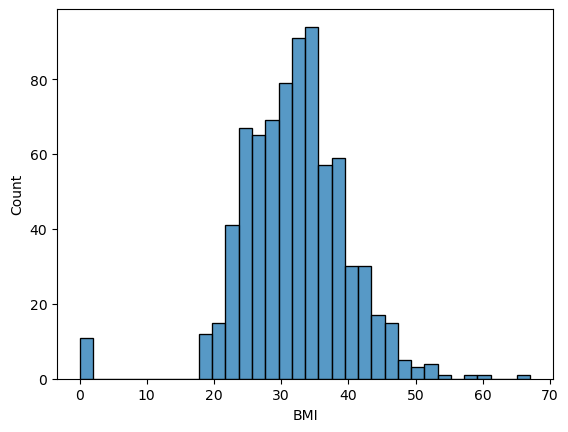

In [30]:
sns.histplot(data=df,x='BMI')

In [36]:
x = df.drop(["BMI_category","Outcome"], axis=1)
y= df['Outcome']
x_train , x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
knn = KNeighborsClassifier(n_neighbors=41)
knn.fit(x_train,y_train)
y_pred= knn.predict(x_test)
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[90  9]
 [32 23]]
0.7337662337662337
              precision    recall  f1-score   support

           0       0.74      0.91      0.81        99
           1       0.72      0.42      0.53        55

    accuracy                           0.73       154
   macro avg       0.73      0.66      0.67       154
weighted avg       0.73      0.73      0.71       154



In [37]:
df.shape

(768, 10)

In [38]:
df =  pd.read_csv("Fish.csv")
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [44]:
x = df.drop(["Species"]
            , axis=1)
y= df['Species']
x_train , x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
for i in range(33,48,2):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train,y_train)
    y_pred= knn.predict(x_test)
    # print(confusion_matrix(y_test,y_pred))
    print(accuracy_score(y_test,y_pred))
    # print(classification_report(y_test,y_pred))
    print(knn.predict([[150,12,15,14,7,6]]))

0.5
['Perch']
0.5
['Perch']
0.5
['Perch']
0.5
['Perch']
0.5
['Perch']
0.5625
['Perch']
0.53125
['Perch']
0.53125
['Perch']


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
C:\Pr